In [1]:
# =========================================================
# STEP 1: Import Libraries
# =========================================================
import os
import pandas as pd
import shutil
from tqdm import tqdm

# =========================================================
# STEP 2: Define Correct Paths
# =========================================================
BASE_PATH = "/kaggle/input/competitions/aptos2019-blindness-detection"

print("Base folders:", os.listdir(BASE_PATH))

TRAIN_IMG_PATH = os.path.join(BASE_PATH, "train_images")
CSV_PATH = os.path.join(BASE_PATH, "train.csv")

OUTPUT_PATH = "/kaggle/working/train_split"

# =========================================================
# STEP 3: Read CSV
# =========================================================
df = pd.read_csv(CSV_PATH)

print("\nCSV Loaded Successfully!")
print(df.head())

print("\nTotal CSV Entries:", len(df))

# =========================================================
# STEP 4: Count Total Images in Train Folder
# =========================================================
total_images = len(os.listdir(TRAIN_IMG_PATH))
print("\nTotal Images in Train Folder:", total_images)

# =========================================================
# STEP 5: Count Labels (0–4)
# =========================================================
label_counts = df['diagnosis'].value_counts().sort_index()

print("\nLabel Counts:")
for label in range(0, 5):
    count = label_counts.get(label, 0)
    print(f"Label {label}: {count}")

# =========================================================
# STEP 6: Create Class Folders
# =========================================================
for label in range(0, 5):
    os.makedirs(os.path.join(OUTPUT_PATH, str(label)), exist_ok=True)

print("\nClass folders created!")

# =========================================================
# STEP 7: Copy Images into Class Folders
# =========================================================
copied = 0
missing = 0

for _, row in tqdm(df.iterrows(), total=len(df)):
    
    image_name = row["id_code"] + ".png"
    label = str(row["diagnosis"])    
    source_path = os.path.join(TRAIN_IMG_PATH, image_name)
    destination_path = os.path.join(OUTPUT_PATH, label, image_name)
    
    if os.path.exists(source_path):
        shutil.copy2(source_path, destination_path)
        copied += 1
    else:
        missing += 1

print(f"\nCopied Images: {copied}")
print(f"Missing Images: {missing}")
print("Output Folder:", OUTPUT_PATH)

# =========================================================
# STEP 8: Create ZIP File
# =========================================================
#ZIP_FILE_NAME = "/kaggle/working/train_split_dataset"

#shutil.make_archive(ZIP_FILE_NAME, 'zip', OUTPUT_PATH)

#print("\nZIP file created successfully!")
#print("Location:", ZIP_FILE_NAME + ".zip")


Base folders: ['sample_submission.csv', 'train_images', 'train.csv', 'test.csv', 'test_images']

CSV Loaded Successfully!
        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0

Total CSV Entries: 3662

Total Images in Train Folder: 3662

Label Counts:
Label 0: 1805
Label 1: 370
Label 2: 999
Label 3: 193
Label 4: 295

Class folders created!


100%|██████████| 3662/3662 [01:59<00:00, 30.53it/s]


Copied Images: 3662
Missing Images: 0
Output Folder: /kaggle/working/train_split


In [2]:
# Cell 1: Install dependencies (already done, but keep for completeness)
!pip install timm transformers

In [3]:
# Cell 2: Imports (removed transformers Swin import, added timm)
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import timm  # For EfficientNet-B5


In [4]:
# Cell 3: Image preprocessing functions (updated resize to 456x456 for EfficientNet-B5)
def crop_retina(img):
    """Crop circular retina region and remove black borders"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) != 0:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        img = img[y+h//4: y+h, x:x+w]
    return img

def apply_clahe(img):
    """Apply CLAHE to enhance contrast (important for microaneurysms)"""
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    img = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)
    return img

def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = crop_retina(img)
    img = apply_clahe(img)
    img = cv2.resize(img, (456, 456))  # EfficientNet-B5 optimal input size
    img = img / 255.0
    img = torch.tensor(img).permute(2, 0, 1).float()
    return img


In [5]:
# Cell 4: RetinaDataset (unchanged)
class RetinaDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        for label in os.listdir(root_dir):
            class_dir = os.path.join(root_dir, label)
            for img_name in os.listdir(class_dir):
                self.image_paths.append(os.path.join(class_dir, img_name))
                self.labels.append(int(label))
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img = preprocess_image(self.image_paths[idx])
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx]).long()
        return img, label


In [6]:
# Cell 5: Load dataset (unchanged)
train_dir = '/kaggle/working/train_split'  # From your dataset preparation
dataset = RetinaDataset(train_dir)
train_loader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=2)


In [9]:
# Cell 6: Initialize EfficientNet-B5 model (replacement for Swin)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load pre-trained EfficientNet-B5 from timm, replace classifier for 5 classes
model = timm.create_model('tf_efficientnet_b5', pretrained=True, num_classes=5)
model = model.to(device)
print(model)


model.safetensors:   0%|          | 0.00/122M [00:00<?, ?B/s]

EfficientNet(
  (conv_stem): Conv2dSame(3, 48, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    48, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
        (bn1): BatchNormAct2d(
          48, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(48, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNo

In [10]:
# Cell 7: Loss, optimizer, scheduler (unchanged)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)


In [11]:
# Cell 8: Training loop (unchanged, works with EfficientNet)
scaler = torch.cuda.amp.GradScaler()
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
    scheduler.step()
    print(f'Epoch {epoch+1}/{epochs} Loss: {running_loss/len(train_loader):.4f}')


/tmp/ipykernel_55/3517246007.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/458 [00:00<?, ?it/s]/tmp/ipykernel_55/3517246007.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 458/458 [06:33<00:00,  1.16it/s]


Epoch 1/10 Loss: 0.8694


100%|██████████| 458/458 [06:15<00:00,  1.22it/s]


Epoch 2/10 Loss: 0.4476


100%|██████████| 458/458 [06:11<00:00,  1.23it/s]


...

Epoch 8/10 Loss: 0.0705


100%|██████████| 458/458 [06:03<00:00,  1.26it/s]


Epoch 9/10 Loss: 0.0624


100%|██████████| 458/458 [06:03<00:00,  1.26it/s]

Epoch 10/10 Loss: 0.0577


In [14]:
# Cell 9: Evaluation (updated for EfficientNet output)
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        outputs = model(images)  # No .logits for timm models
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')
print(f'Accuracy: {acc:.4f} F1 Score: {f1:.4f}')


Accuracy: 0.9896 F1 Score: 0.9897


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1805
           1       0.98      0.99      0.99       370
           2       1.00      0.98      0.99       999
           3       0.94      0.97      0.95       193
           4       0.95      0.99      0.97       295

    accuracy                           0.99      3662
   macro avg       0.97      0.98      0.98      3662
weighted avg       0.99      0.99      0.99      3662



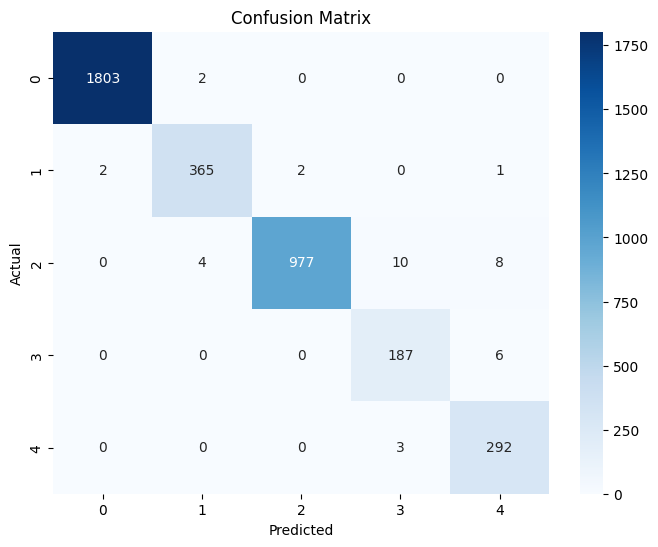

In [15]:
# Cell 10: Classification report and confusion matrix (unchanged)
print(classification_report(all_labels, all_preds))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [16]:
# Cell 11: Save model (timm format)
torch.save(model.state_dict(), '/kaggle/working/efficientnetb5_trained.pth')
print('Model saved successfully!')


Model saved successfully!


In [18]:
# Cell 14: Load trained model for testing
model = timm.create_model('tf_efficientnet_b5', pretrained=False, num_classes=5)
model.load_state_dict(torch.load('/kaggle/working/efficientnetb5_trained.pth'))
model = model.to(device)
model.eval()
print("Model loaded successfully!")


Model loaded successfully!


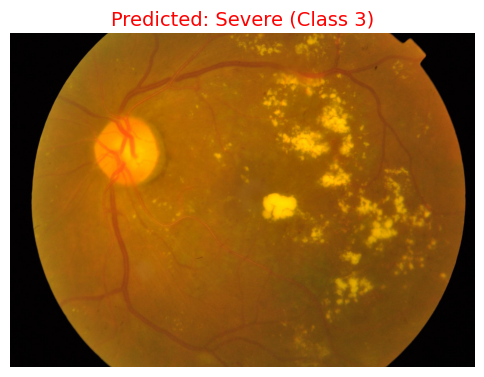

🎯 Predicted Class Number: 3
🩺 DR Severity Type: Severe


In [31]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import os

# ---- Class Names (Change if needed) ----
class_names = ["No_DR", "Mild", "Moderate", "Severe", "Proliferative_DR"]

# ---- Image Path ----
image_path = "/kaggle/input/competitions/aptos2019-blindness-detection/train_images/0104b032c141.png"

# ---- Load Original Image (for display) ----
original_img = Image.open(image_path).convert("RGB")

# ---- Preprocess Image ----
img = preprocess_image(image_path)
img = img.unsqueeze(0).to(device)

# ---- Prediction ----
model.eval()
with torch.no_grad():
    outputs = model(img)
    pred = torch.argmax(outputs, dim=1).item()

predicted_name = class_names[pred]

# ---- Display Image with Prediction ----
plt.figure(figsize=(6,6))
plt.imshow(original_img)
plt.axis("off")
plt.title(f"Predicted: {predicted_name} (Class {pred})", fontsize=14, color="red")
plt.show()

# ---- Print Result ----
print(f"🎯 Predicted Class Number: {pred}")
print(f"🩺 DR Severity Type: {predicted_name}")